In [1]:
# Install dependencies
%pip install nested-pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import nested_pandas as npd
import numpy as np

In [3]:
### --- Edit to the path to "dataset" directory --- ###
df = npd.read_parquet('zubercal_vcep/dataset/', partitioning=None, columns=["Source", "lc"])

# Shift times to the first observation for each light curve
df = df.map_rows(lambda row: {"lc.t": row["lc.mjd"] - row["lc.mjd"][0]}, append_columns=True)

# Convert magnitudes to fluxes in nJy, magnitudes are in AB system
df["lc.flux"] = 10**(0.4 * (31.4 - df["lc.mag"]))

# Convert magerr to nJy using error propagation formula.
# Note that magerr is given in 1e-4 mag
df["lc.err"] = 0.4 * np.log(10.0) * 1e-4 * df["lc.magerr"] * df["lc.flux"]

# Convert bands to decimal logarithm of effective wavelength in angstroms
# Values are from https://svo2.cab.inta-csic.es/svo/theory/fps3/index.php?mode=browse&gname=Palomar&gname2=ZTF&asttype=
band_to_lgwave = {"g": np.log10(4746.48), "r": np.log10(6366.38), "i": np.log10(7829.03)}
df["lc.lgwave"] = df["lc.band"].map(band_to_lgwave)

# Drop old columns, keep "band" for plots
df = df.drop(columns=["lc.mjd", "lc.mag", "lc.magerr"])
df

Source                                                 lc
0       61259706956316800  [{band: 'r', t: 0.0, flux: 1.599853e+06, err: ...
1      175811260743708672  [{band: 'g', t: 0.0, flux: 5.926521e+06, err: ...
...                   ...                                                ...
3056  5717854265702401792  [{band: 'g', t: 0.0, flux: 6.001226e+07, err: ...
3057  5750171867369677440  [{band: 'r', t: 0.0, flux: 4.017540e+07, err: ...

[3058 rows x 2 columns]

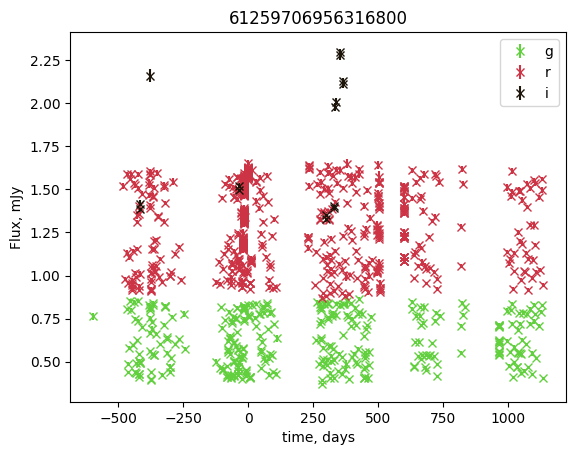

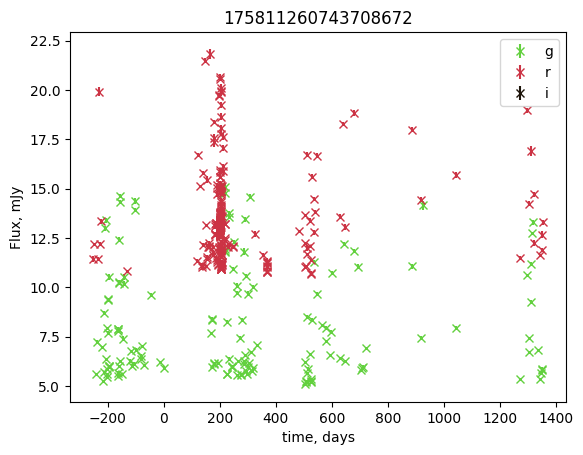

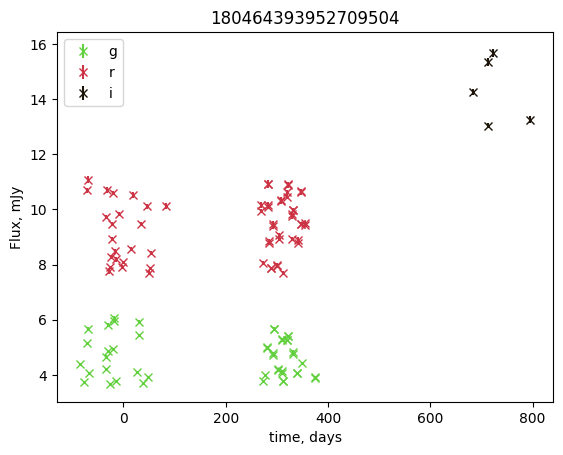

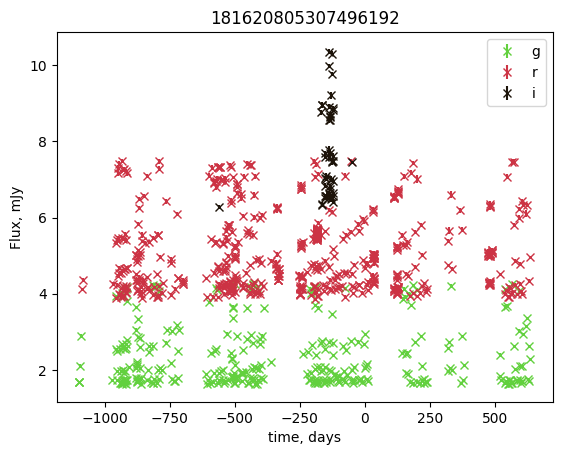

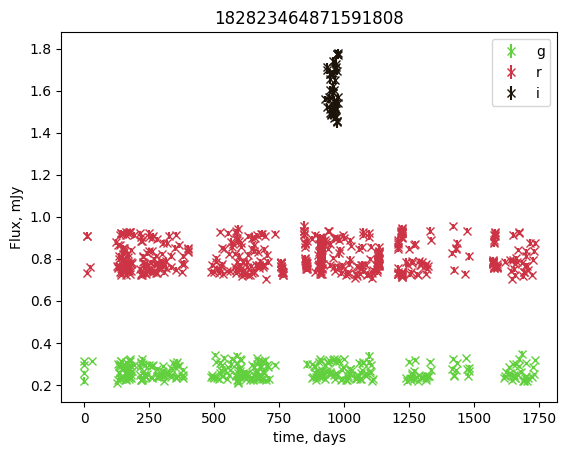

In [4]:
# Plot first five light curves

for _idx, row in df.iloc[:5].iterrows():
    source = row["Source"]
    # lc is a pandas dataframe
    lc = row["lc"]
    plt.figure()
    for band, color in [("g", "#62D03E"), ("r", "#CC3344"), ("i", "#1c1309")]:
        data = lc[lc.band == band]
        plt.errorbar(data["t"], 1e-6*data["flux"], 1e-6*data["err"], color=color, ls="", marker="x", label=band)
    plt.xlabel("time, days")
    plt.ylabel("Flux, mJy")
    plt.title(source)
    plt.legend()